<a href="https://colab.research.google.com/github/folonidaniel4/Redes-Neurais/blob/main/Arvore_de_Decisao_Jogar_Tenis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import random
random.seed(1)

#Carregando os dados
dados = pd.read_csv('https://raw.githubusercontent.com/cibelerusso/Datasets/refs/heads/main/jogartenis_aumentado.csv')
dados

,Unnamed: 0,Tempo,Temperatura,Umidade,Vento,Joga
0,0,Ensolarado,23,70,Não,Sim
1,1,Chuvoso,18,82,Não,Sim
2,2,Chuvoso,26,60,Sim,Não
3,3,Nublado,18,96,Não,Sim
4,4,Ensolarado,22,80,Sim,Sim
...,...,...,...,...,...,...
495,495,Ensolarado,20,91,Sim,Não
496,496,Nublado,30,70,Não,Sim
497,497,Ensolarado,25,82,Não,Sim
498,498,Chuvoso,26,85,Sim,Não


In [2]:
dados['Tempo'] = dados['Tempo'].map({'Ensolarado':1,'Nublado':2,'Chuvoso':3})
dados['Vento'] = dados['Vento'].map({'Sim':1,'Não':0})
dados['Joga'] = dados['Joga'].map({'Sim':1,'Não':0})
dados

,Unnamed: 0,Tempo,Temperatura,Umidade,Vento,Joga
0,0,1,23,70,0,1
1,1,3,18,82,0,1
2,2,3,26,60,1,0
3,3,2,18,96,0,1
4,4,1,22,80,1,1
...,...,...,...,...,...,...
495,495,1,20,91,1,0
496,496,2,30,70,0,1
497,497,1,25,82,0,1
498,498,3,26,85,1,0


In [3]:
#Separa x e y
X = dados.drop('Joga', axis=1)
y = dados['Joga']

#Dados de treinamento e teste: 80% para treinamento e 20% para teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train

,Unnamed: 0,Tempo,Temperatura,Umidade,Vento
5,5,1,21,85,1
116,116,3,24,78,0
45,45,2,22,99,0
16,16,1,26,94,0
462,462,3,28,87,1
...,...,...,...,...,...
106,106,2,19,73,0
270,270,3,23,82,1
348,348,1,18,79,1
435,435,3,18,98,1


In [4]:
#Cria uma árvore de decisão
arvore = DecisionTreeClassifier(max_depth=5, criterion='entropy')

#Treina a árvore de decisão usando os dados de treinamento
arvore.fit(X_train, y_train)

#Usa a árvore de decisão para prever os rótulos da base teste
y_pred = arvore.predict(X_test)
y_pred

array([1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [5]:
y_test

,Joga
361,1
73,0
374,0
155,1
104,0
...,...
266,1
23,1
222,1
261,1


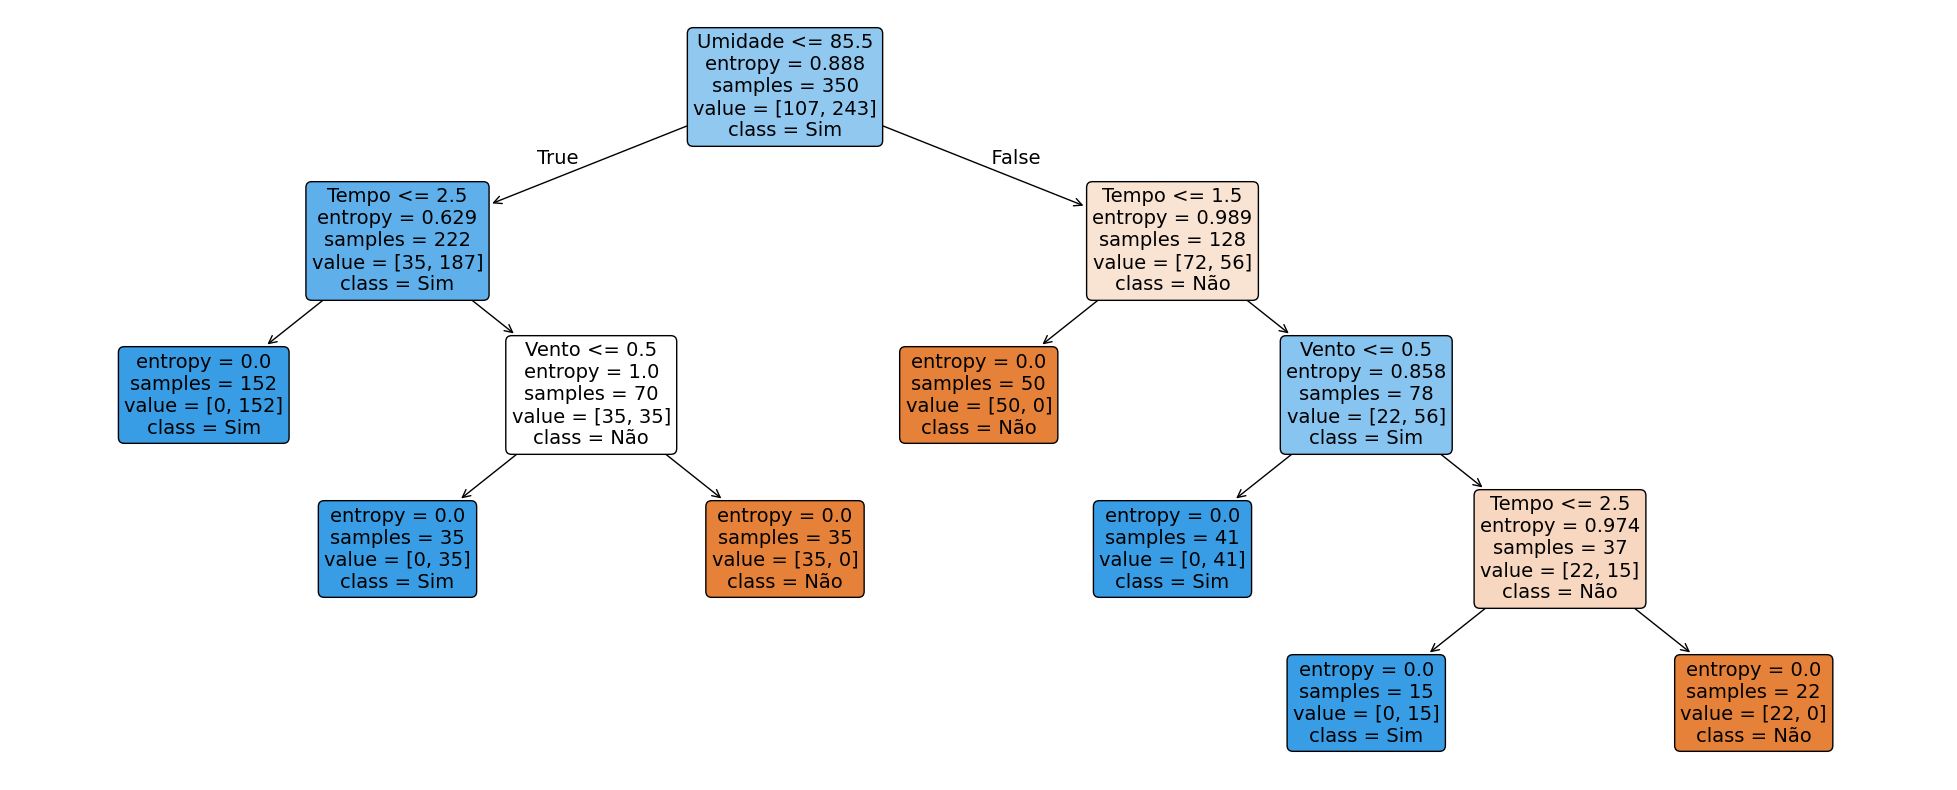

In [6]:
plt.figure(figsize=(25,10))

a = plot_tree(arvore, feature_names=X_train.columns, class_names=['Não','Sim'], filled=True, rounded=True, fontsize=14)

In [7]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

#Acurácia
acuracia = accuracy_score(y_pred, y_test)

print('Métricas de Desempenho para aprendizado supervisionado em classificação binária')
print('\nAcurácia: ',np.round(acuracia,3))

#Para a classe 1:
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)
print('\nPrecisão para classe 1: ',np.round(precision,3))
print('Recall para classe 1: ',np.round(recall,3))
print('F1 para classe 1: ',np.round(f1,3))

#Para a classe 0:
precision = precision_score(y_test, y_pred, pos_label=0)
recall = recall_score(y_test, y_pred, pos_label=0)
f1 = f1_score(y_test, y_pred, pos_label=0)
print('\nPrecisão para classe 0: ',np.round(precision,3))
print('Recall para classe 0: ',np.round(recall,3))
print('F1 para classe 0: ',np.round(f1,3))

Métricas de Desempenho para aprendizado supervisionado em classificação binária

Acurácia:  1.0

Precisão para classe 1:  1.0
Recall para classe 1:  1.0
F1 para classe 1:  1.0

Precisão para classe 0:  1.0
Recall para classe 0:  1.0
F1 para classe 0:  1.0
